In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (14, 8)

In [2]:
def load_results(results_folder):
    result_files = [f for f in os.listdir(results_folder) if f.endswith('.json')]
    results = {}
    
    for file in result_files:
        file_path = os.path.join(results_folder, file)
        with open(file_path, 'r') as f:
            results[file] = json.load(f)
    
    return results

In [3]:
def extract_detailed_node_metrics(results, experiment_name):
    """Extract detailed node metrics including platform results"""
    node_data = []
    platform_data = []
    storage_data = []

    for result_file, result in results.items():
        if 'nodeResults' in result['stats']:
            for node in result['stats']['nodeResults']:
                # Basic node metrics
                node_metrics = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'node_id': node['nodeId'],
                    'unused': node.get('unused', False),
                    'scheduling_time': node.get('schedulingTime', 0),
                    'storage_time': node.get('storageTime', 0),
                    'local_dependencies': node.get('localDependencies', 0),
                    'cache_hits': node.get('cacheHits', 0),
                }

                # Energy metrics by platform type
                if 'energy' in node:
                    for platform_type, energy in node['energy'].items():
                        node_metrics[f'energy_{platform_type}'] = energy

                # Idle energy metrics
                if 'energyIdle' in node:
                    for platform_type, energy in node['energyIdle'].items():
                        node_metrics[f'idle_energy_{platform_type}'] = energy

                # Idle time metrics
                if 'idleTime' in node:
                    for platform_type, time_val in node['idleTime'].items():
                        node_metrics[f'idle_time_{platform_type}'] = time_val

                node_data.append(node_metrics)

                # Platform detailed metrics
                if 'platformResults' in node:
                    for platform in node['platformResults']:
                        platform_metrics = {
                            'experiment': experiment_name,
                            'file': result_file,
                            'node_id': node['nodeId'],
                            'platform_id': platform['platformId'],
                            'platform_type': platform['platformType']['shortName'],
                            'platform_hardware': platform['platformType']['hardware'],
                            'platform_price': platform['platformType']['price'],
                            'energy': platform.get('energy', 0),
                            'energy_idle': platform.get('energyIdle', 0),
                            'idle_time': platform.get('idleTime', 0),
                            'idle_proportion': platform.get('idleProportion', 0),
                            'storage_time': platform.get('storageTime', 0)
                        }
                        platform_data.append(platform_metrics)

                # todo: which are static and can serve as inputs, which are results of the simulation?
                # Storage metrics
                if 'storageResults' in node:
                    for storage in node['storageResults']:
                        storage_metrics = {
                            'experiment': experiment_name,
                            'file': result_file,
                            'node_id': node['nodeId'],
                            'storage_id': storage['storageId'],
                            'has_usage_data': len(storage.get('totalUsage', [])) > 0
                        }
                        storage_data.append(storage_metrics)

    return pd.DataFrame(node_data), pd.DataFrame(platform_data), pd.DataFrame(storage_data)

In [4]:
def extract_detailed_task_metrics(results, experiment_name):
    """Extract detailed task metrics"""
    tasks_data = []

    for result_file, result in results.items():
        if 'taskResults' in result['stats']:
            for task in result['stats']['taskResults']:
                task_data = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'task_id': task['taskId'],
                    'dispatched_time': task['dispatchedTime'],
                    'scheduled_time': task['scheduledTime'],
                    'arrived_time': task['arrivedTime'],
                    'started_time': task['startedTime'],
                    'done_time': task['doneTime'],
                    'task_type': task['taskType']['name'],
                    'platform_type': task['platform']['shortName'],
                    'platform_hardware': task['platform']['hardware'],
                    'elapsed_time': task['elapsedTime'],
                    'pull_time': task.get('pullTime', 0),
                    'cold_start_time': task.get('coldStartTime', 0),
                    'execution_time': task.get('executionTime', 0),
                    'wait_time': task.get('waitTime', 0),
                    'queue_time': task.get('queueTime', 0),
                    'initialization_time': task.get('initializationTime', 0),
                    'compute_time': task.get('computeTime', 0),
                    'communications_time': task.get('communicationsTime', 0),
                    'cold_started': task.get('coldStarted', False),
                    'cache_hit': task.get('cacheHit', False),
                    'local_dependencies': task.get('localDependencies', False),
                    'local_communications': task.get('localCommunications', False),
                    'energy': task.get('energy', 0),
                    'network_latency': task['networkLatency'],
                    'source_node': task['sourceNode'],
                    'execution_node': task['executionNode']
                }

                # Calculate task latency components
                task_data['scheduling_latency'] = task_data['scheduled_time'] - task_data['dispatched_time']
                task_data['arrival_latency'] = task_data['arrived_time'] - task_data['scheduled_time']
                task_data['start_latency'] = task_data['started_time'] - task_data['arrived_time']
                task_data['processing_latency'] = task_data['done_time'] - task_data['started_time']
                task_data['end_to_end_latency'] = task_data['done_time'] - task_data['dispatched_time']

                tasks_data.append(task_data)

    return pd.DataFrame(tasks_data)

In [5]:
from collections import defaultdict

experiments = {
    "knative": "/root/projects/my-herosim/src/notebooks/data/results_sim/125-225-5clients-knative-with-network",
}

experiment_data = {}

for name, folder in experiments.items():
    results = load_results(folder)
    node_df, platform_df, storage_df = extract_detailed_node_metrics(results, name)
    task_df = extract_detailed_task_metrics(results, name)
    experiment_data[name] = {
        "node_df": node_df,
        "platform_df": platform_df,
        "storage_df": storage_df,
        "task_df": task_df
    }

In [6]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, BatchNorm
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import numpy as np
from tqdm import tqdm
import logging
import time
from typing import Dict, List, Tuple, Optional

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("training.log"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger()

In [ ]:
def create_node_features_from_stats(node_data, platform_data, storage_data):
    """Create node features from simulation statistics"""
    node_features = {}

    for node_id in node_data['node_id'].unique():
        # Get node's data
        node_info = node_data[node_data['node_id'] == node_id].iloc[0]
        node_platforms = platform_data[platform_data['node_id'] == node_id]
        # node_storage = storage_data[storage_data['node_id'] == node_id]

        features = []

        # Basic node resources
        features.extend([len(node_platforms)])
        # assert 'memory' in node_info, f"Missing memory for node {node_id}"
        features.extend([node_info['memory'] if 'memory' in node_info else 8.0])

        # Platform-related features
        platform_counts = defaultdict(int)
        platform_utilization = defaultdict(list)

        for _, platform in node_platforms.iterrows():
            platform_type = platform['platform_type']
            platform_counts[platform_type] += 1
            # Convert idle_proportion to utilization
            utilization = 100 - platform['idle_proportion'] if 'idle_proportion' in platform else 0
            platform_utilization[platform_type].append(utilization)

        # Add platform features (ensure consistent ordering)
        platform_types = sorted(set(platform_data['platform_type'].unique()))
        for p_type in platform_types:
            features.append(platform_counts[p_type])
            avg_util = (sum(platform_utilization[p_type]) / len(platform_utilization[p_type])
                       if platform_utilization[p_type] else 0)
            features.append(avg_util)

        # todo:
        """
        # Storage-related features
        storage_features = []
        for _, storage in node_storage.iterrows():
            # Using default values if not available
            storage_features.extend([
                100.0,  # Default capacity 100GB
                1000.0,  # Default read throughput 1000MB/s
                1000.0,  # Default write throughput 1000MB/s
                0.001,  # Default read latency 1ms
                0.001,  # Default write latency 1ms
                0.0,    # Default not remote
            ])

        # If no storage, add zeros
        if not storage_features:
            storage_features = [0.0] * 6

        features.extend(storage_features)
        """
        node_features[node_id] = features

    return node_features

In [ ]:
def prepare_gnn_training_data(tasks_df, node_df, platform_df, storage_df, batch_size=1024):
    """Prepare training data with enhanced node features"""
    print("Preparing node mappings...")

    # node_df['node_id'] = node_df['node_id'].astype(str).apply(lambda x: f'node{x}')
    node_df['node_id'] = node_df['node_id'].apply(normalize_node_id)

    # Normalize execution_node and source_node in tasks_df
    tasks_df['execution_node'] = tasks_df['execution_node'].apply(normalize_node_id)
    tasks_df['source_node'] = tasks_df['source_node'].apply(normalize_node_id)

    # Fixed list of nodes (ensure consistent ordering)
    unique_nodes = sorted(node_df['node_id'].unique())
    node_to_idx = {node: idx for idx, node in enumerate(unique_nodes)}

    print("Nodes in node_df:", sorted(node_df['node_id'].unique()))
    print("Execution nodes in tasks_df:", sorted(tasks_df['execution_node'].unique()))

    print(f"Using {len(unique_nodes)} nodes")

    # Create node features
    print("Creating node features...")
    node_features = create_node_features_from_stats(node_df, platform_df, storage_df)

    # Convert node features to tensor and normalize
    print("Normalizing node features...")
    feature_matrix = np.array([node_features[node] for node in unique_nodes])
    node_scaler = StandardScaler()
    normalized_node_features = node_scaler.fit_transform(feature_matrix)

    print("Encoding task types...")
    task_types = tasks_df['task_type'].unique()
    task_encoder = {task: idx for idx, task in enumerate(task_types)}
    print(f"Found {len(task_types)} unique task types")

    print("Processing task features...")
    tasks_df_processed = tasks_df.copy()

    # Normalize task-specific features
    task_scaler = StandardScaler()
    tasks_df_processed['network_latency_scaled'] = task_scaler.fit_transform(tasks_df[['network_latency']])
    tasks_df_processed['compute_time_scaled'] = task_scaler.fit_transform(tasks_df[['compute_time']])
    tasks_df_processed['task_type_encoded'] = tasks_df['task_type'].map(task_encoder)

    return (tasks_df_processed, node_to_idx, task_encoder,
            normalized_node_features, node_scaler, task_scaler)

def normalize_node_id(node_id):
    """Ensure all node IDs are in 'nodeX' string format."""
    node_id_str = str(node_id)
    if node_id_str.startswith("node"):
        return node_id_str
    return f"node{node_id_str}"

In [9]:
def create_graph_data(training_data_df, node_to_idx, normalized_node_features):
    """Convert training data into PyG graph data objects with enhanced features"""
    graphs = []
    num_nodes = len(node_to_idx)

    # Convert normalized node features to tensor once
    base_node_features = torch.tensor(normalized_node_features, dtype=torch.float)

    print(f"Total training samples: {len(training_data_df)}")
    start_time = time.time()
    timing_samples = 10000

    # Precompute latency lookup
    latency_lookup = (training_data_df.groupby(['source_node', 'execution_node'])
                     ['network_latency_scaled'].mean().to_dict())

    for idx, row in tqdm(training_data_df.iterrows(), total=len(training_data_df), bar_format='{l_bar}{bar:10}{r_bar}{bar:-10b}'):
        # Use normalized node features
        x = base_node_features.clone()

        # Create edges and edge features
        edge_index = []
        edge_attr = []
        for source in node_to_idx.keys():
            for target in node_to_idx.keys():
                if source != target:
                    edge_index.append([node_to_idx[source], node_to_idx[target]])
                    latency = latency_lookup.get((source, target), 0)
                    edge_attr.append(latency if not np.isnan(latency) else 0)

        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

        # Create task features
        # todo: tasks have only 2 features
        task_features = torch.zeros((num_nodes, 2))
        task_features[:, 0] = row['task_type_encoded']
        task_features[:, 1] = row['compute_time_scaled']

        # Create target
        y = torch.tensor(node_to_idx[row['execution_node']], dtype=torch.long)

        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                   task_features=task_features, y=y)
        graphs.append(data)

        if idx + 1 == timing_samples:
            elapsed_time = time.time() - start_time
            avg_time = elapsed_time / timing_samples
            estimated_total = avg_time * len(training_data_df)
            # print(f"First {timing_samples} iterations took {elapsed_time:.2f} seconds")
            # print(f"Average time per graph: {avg_time:.4f} seconds")
            # print(f"Estimated total time: {estimated_total:.2f} seconds ({estimated_total/60:.2f} minutes)")

    # print(f"Actual total time: {time.time() - start_time:.2f} seconds")
    return graphs

In [ ]:
prepared_data = {}

for name, data in experiment_data.items():
    print(f"\nPreparing training data for: {name}")
    (task_df_proc, node_to_idx, task_encoder,
     node_features, node_scaler, task_scaler) = prepare_gnn_training_data(
        data["task_df"], data["node_df"], data["platform_df"], data["storage_df"]
    )
    prepared_data[name] = {
        "task_df": task_df_proc,
        "node_to_idx": node_to_idx,
        "task_encoder": task_encoder,
        "node_features": node_features,
        "node_scaler": node_scaler,
        "task_scaler": task_scaler
    }


Preparing training data for: knative
Preparing node mappings...
Nodes in node_df: ['node0', 'node1', 'node2', 'node3', 'node4', 'node5', 'node6', 'node7', 'node8', 'node9']
Execution nodes in tasks_df: ['node0', 'node1', 'node2', 'node3', 'node4', 'node5', 'node6', 'node7']
Using 10 nodes
Creating node features...
Normalizing node features...
Encoding task types...
Found 2 unique task types
Processing task features...


In [11]:
graph_datasets = {}

for name, data in prepared_data.items():
    graphs = create_graph_data(
        data["task_df"],
        data["node_to_idx"],
        data["node_features"]
    )
    graph_datasets[name] = graphs

Total training samples: 1873393


100%|██████████| 1873393/1873393 [08:16<00:00, 3772.52it/s]                                                                                 


In [12]:
# merge all graphs in one list
from itertools import chain

all_graphs = list(chain.from_iterable(graph_datasets.values()))
print(f"Total graphs for joint training: {len(all_graphs)}")

def any_tensor_on_cuda(graphs):
    return any(any(t.is_cuda for _, t in g) for g in graphs)

print("Any CUDA tensors?", any_tensor_on_cuda(all_graphs))

Total graphs for joint training: 1873393
Any CUDA tensors? False


In [13]:
sample_graph = all_graphs[0]
num_node_features = sample_graph.x.size(1)
num_task_features = sample_graph.task_features.size(1)

In [14]:
class SchedulerGNN(torch.nn.Module):
    def __init__(self, num_node_features: int, num_task_features: int, num_nodes: int, hidden_channels: int = 64):
        super().__init__()
        self.num_node_features = num_node_features
        self.num_task_features = num_task_features
        self.hidden_channels = hidden_channels
        self.num_nodes = num_nodes

        # Node feature processing with residual connection
        self.node_encoder = torch.nn.Sequential(
            torch.nn.Linear(num_node_features, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.BatchNorm1d(hidden_channels),
            torch.nn.Dropout(0.3)
        )

        # Two GCN layers with skip connection
        self.conv1 = GCNConv(hidden_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn1 = BatchNorm(hidden_channels)
        self.bn2 = BatchNorm(hidden_channels)

        # Task feature processing with wider network
        self.task_encoder = torch.nn.Sequential(
            torch.nn.Linear(num_task_features, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.BatchNorm1d(hidden_channels),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(hidden_channels, hidden_channels // 2),
            torch.nn.ReLU(),
            torch.nn.BatchNorm1d(hidden_channels // 2)
        )

        # Final MLP for node selection
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels + hidden_channels // 2, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.BatchNorm1d(hidden_channels),
            torch.nn.Linear(hidden_channels, 1)  # Output a single score per node
        )

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor,
                edge_attr: torch.Tensor, task_features: torch.Tensor) -> torch.Tensor:
        # Process node features with residual connection
        node_features = self.node_encoder(x)  # [num_nodes * batch_size, hidden_channels]
        x = node_features

        # Apply first graph convolution with edge features
        edge_weight = edge_attr.view(-1)  # Ensure edge attributes are 1D
        x1 = self.conv1(x, edge_index, edge_weight)
        x1 = self.bn1(x1)
        x1 = F.relu(x1)
        x1 = F.dropout(x1, p=0.1, training=self.training)

        # Apply second graph convolution with skip connection
        x2 = self.conv2(x1, edge_index, edge_weight)
        x2 = self.bn2(x2)
        x2 = F.relu(x2)
        x2 = F.dropout(x2, p=0.1, training=self.training)

        # Combine with skip connection
        x = x2 + x1 + node_features  # Residual connections

        # Process task features for each node
        task_x = self.task_encoder(task_features)  # [num_nodes, hidden_channels]

        # Combine node and task features with attention
        combined = torch.cat([x, task_x], dim=1)  # [num_nodes * batch_size, 2*hidden_channels]

        # Get node scores
        scores = self.mlp(combined).squeeze(-1)  # [num_nodes * batch_size]

        # Reshape scores for batch processing
        scores = scores.view(-1, self.num_nodes)  # [batch_size, num_nodes]

        return F.log_softmax(scores, dim=1)  # Apply log_softmax for numerical stability

In [15]:
from sklearn.model_selection import train_test_split

def train_model(
    model: SchedulerGNN,
    all_graphs: List[torch.Tensor],
    epochs: int = 10,
    batch_size: int = 32,
    checkpoint_path: str = 'gnn_scheduler_model.pt',
    num_workers: int = 4
) -> Tuple[SchedulerGNN, Dict]:
    """Train the GNN model with enhanced training loop"""
    logger.info(f"Splitting {len(all_graphs)} graphs into train/val sets...")

    # Get the label distribution
    labels = [g.y.item() for g in all_graphs]

    train_graphs, val_graphs = train_test_split(
        all_graphs, test_size=0.2, stratify=labels, random_state=42
    )

    # Use multiple workers for data loading
    train_loader = DataLoader(
        train_graphs,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_graphs,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    logger.info(f"Using device: {device}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )

    best_val_loss = float('inf')
    best_val_acc = 0.0
    # todo: patience
    patience = 30
    patience_counter = 0

    metrics = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'learning_rates': []
    }

    for epoch in range(epochs):
        logger.info(f"Epoch {epoch+1}/{epochs} starting...")
        epoch_start = time.time()

        # Training
        model.train()
        train_stats = train_epoch(model, train_loader, optimizer, device)

        # Validation
        model.eval()
        val_stats = validate_epoch(model, val_loader, device)

        # Update learning rate
        scheduler.step(val_stats['loss'])

        # Log metrics
        metrics['train_loss'].append(train_stats['loss'])
        metrics['train_acc'].append(train_stats['acc'])
        metrics['val_loss'].append(val_stats['loss'])
        metrics['val_acc'].append(val_stats['acc'])
        metrics['learning_rates'].append(optimizer.param_groups[0]['lr'])

        # Save best model
        if val_stats['loss'] < best_val_loss:
            best_val_loss = val_stats['loss']
            best_val_acc = val_stats['acc']
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_loss': best_val_loss,
                'val_acc': best_val_acc,
            }, checkpoint_path)
            patience_counter = 0
            logger.info(f"New best model saved! Val Loss: {best_val_loss:.4f}, Val Acc: {best_val_acc:.4f}")
        else:
            patience_counter += 1

        epoch_time = time.time() - epoch_start
        logger.info(
            f"Epoch {epoch+1:03d} Summary | "
            f"Train Loss: {train_stats['loss']:.4f}, Acc: {train_stats['acc']:.4f} | "
            f"Val Loss: {val_stats['loss']:.4f}, Acc: {val_stats['acc']:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.6f} | "
            f"Time: {epoch_time:.2f}s"
        )

        if patience_counter >= patience:
            logger.info(f"Early stopping triggered after {epoch+1} epochs")
            break

    return model, metrics

def train_epoch(model: SchedulerGNN, train_loader: DataLoader,
                optimizer: torch.optim.Optimizer, device: torch.device) -> Dict:
    """Run one training epoch with improved training stability"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(train_loader, desc="Training"):
        batch = batch.to(device)
        optimizer.zero_grad(set_to_none=True)  # More efficient than zero_grad()

        # Forward pass
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.task_features)
        target = batch.y  # y is already in index format
        loss = F.nll_loss(out, target)  # Use NLL loss since we're using log_softmax

        # Backward pass with gradient clipping
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Track metrics
        total_loss += loss.item()
        pred = out.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)

        # Free up memory
        del loss, out, pred
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return {
        'loss': total_loss / len(train_loader),
        'acc': correct / total
    }

def validate_epoch(model: SchedulerGNN, val_loader: DataLoader,
                  device: torch.device) -> Dict:
    """Run validation epoch with improved stability"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            batch = batch.to(device)

            # Forward pass
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.task_features)
            target = batch.y  # y is already in index format
            loss = F.nll_loss(out, target)  # Use NLL loss since we're using log_softmax

            # Track metrics
            total_loss += loss.item()
            pred = out.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)

            # Free up memory
            del loss, out, pred
            torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return {
        'loss': total_loss / len(val_loader),
        'acc': correct / total
    }

In [16]:
def test_model(model: SchedulerGNN, test_loader: DataLoader,
               device: torch.device) -> Dict:
    """Test the model on a test set"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    predictions = []
    targets = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            batch = batch.to(device)
            
            # Forward pass
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.task_features)
            target = batch.y  # y is already in index format
            loss = F.cross_entropy(out, target)

            # Track metrics
            total_loss += loss.item()
            pred = out.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)

            # Store predictions and targets for additional metrics
            predictions.extend(pred.cpu().numpy())
            targets.extend(target.cpu().numpy())

    accuracy = correct / total
    avg_loss = total_loss / len(test_loader)

    # Calculate additional metrics
    from sklearn.metrics import precision_score, recall_score, f1_score
    precision = precision_score(targets, predictions, average='weighted')
    recall = recall_score(targets, predictions, average='weighted')
    f1 = f1_score(targets, predictions, average='weighted')

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

def plot_training_metrics(metrics: Dict):
    """Plot training metrics"""
    plt.figure(figsize=(15, 5))

    # Plot loss
    plt.subplot(1, 3, 1)
    plt.plot(metrics['train_loss'], label='Train Loss')
    plt.plot(metrics['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 3, 2)
    plt.plot(metrics['train_acc'], label='Train Acc')
    plt.plot(metrics['val_acc'], label='Val Acc')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot learning rate
    plt.subplot(1, 3, 3)
    plt.plot(metrics['learning_rates'])
    plt.title('Learning Rate over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')

    plt.tight_layout()
    plt.show()

[2025-06-23 09:51:38,900] INFO - Splitting 1873393 graphs into train/val sets...
[2025-06-23 09:51:42,057] INFO - Using device: cuda
[2025-06-23 09:51:42,059] INFO - Epoch 1/50 starting...
Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1464/1464 [00:18<00:00, 80.41it/s]
[2025-06-23 09:53:25,862] INFO - New best model saved! Val Loss: 2.3641, Val Acc: 0.0504
[2025-06-23 09:53:25,863] INFO - Epoch 001 Summary | Train Loss: 2.0110, Acc: 0.1898 | Val Loss: 2.3641, Acc: 0.0504 | LR: 0.001000 | Time: 103.80s
[2025-06-23 09:53:25,863] INFO - Epoch 2/50 starting...
Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1464/1464 [00:17<00:00, 84.14it/s]
[2025-06-23 09:55:10,367] INFO - New best model saved! Val Loss: 2.0652, Val Acc: 0.2437
[2025-06-23 09:55:10,367] INFO - Epoch 002 Summary | Train Loss: 1.9104, Acc: 0.2194 | Val Loss: 2.0652, Acc: 0.2437 | LR: 0.001000 | Time: 104.50s

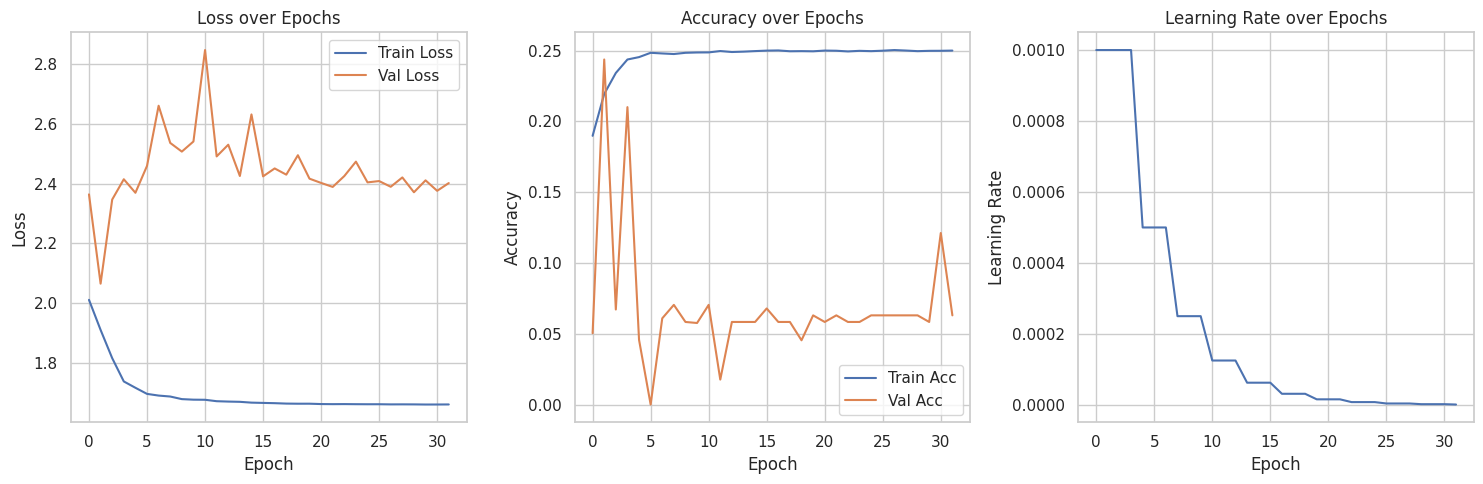

Testing: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 1464/1464 [00:13<00:00, 108.96it/s]
/root/.local/share/virtualenvs/my-herosim-7iPRbgpb/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Test Results:
loss: 2.3978
accuracy: 0.0633
precision: 0.0214
recall: 0.0633
f1_score: 0.0320


In [17]:
# Initialize and train the model with improved parameters
number_of_nodes = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SchedulerGNN(num_node_features, num_task_features, number_of_nodes)

# Initialize weights properly
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)
model.apply(init_weights)

model = model.to(device) # <-- THIS is essential

# Train the model with adjusted parameters
trained_model, metrics = train_model(
    model,
    all_graphs,
    epochs=50,
    batch_size=256,  # Increased batch size
    num_workers=0  # Disable multiprocessing for now
)

# Plot training metrics
plot_training_metrics(metrics)

# Create test loader with same parameters
test_loader = DataLoader(
    all_graphs[-len(all_graphs)//5:],  # Use last 20% as test set
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Test the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_metrics = test_model(trained_model, test_loader, device)

print("\nTest Results:")
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")

In [18]:
import time

# Measure inference time
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = trained_model.to(device)
model.eval()

inference_times = []
n_samples = 1000

with torch.no_grad():
    for i, graph in enumerate(all_graphs[:n_samples]):
        graph = graph.to(device)

        start_time = time.time()
        _ = model(graph.x, graph.edge_index, graph.edge_attr, graph.task_features)
        end_time = time.time()

        inference_times.append(end_time - start_time)

avg_time = sum(inference_times) / len(inference_times)
print(f"Average inference time per graph (decision): {avg_time * 1000:.3f} ms")

Average inference time per graph (decision): 1.853 ms


In [19]:
from torch_geometric.loader import DataLoader

# Set batch size for throughput measurement
batch_size = 256
test_loader = DataLoader(all_graphs[:1000], batch_size=batch_size, shuffle=False)

start_time = time.time()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        _ = model(batch.x, batch.edge_index, batch.edge_attr, batch.task_features)
end_time = time.time()

total_time = end_time - start_time
total_samples = len(test_loader.dataset)
throughput = total_samples / total_time

print(f"Batched inference throughput: {throughput:.2f} graphs/sec")
print(f"Average batch inference time: {total_time / len(test_loader):.4f} sec/batch")

Batched inference throughput: 16473.58 graphs/sec
Average batch inference time: 0.0152 sec/batch


In [20]:
from sklearn.model_selection import train_test_split

# Get the label distribution
labels = [g.y.item() for g in all_graphs]

train_graphs, val_graphs = train_test_split(
    all_graphs, test_size=0.2, stratify=labels, random_state=42
)

In [21]:
# Evaluate the model and output raw scores
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print("Testing and printing scores for the first few batches...\n")

from torch_geometric.loader import DataLoader

test_loader = DataLoader(
    all_graphs[-len(all_graphs)//5:],  # Use last 20% as test set
    batch_size=4,  # Small batch size for readable output
    shuffle=False
)

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.task_features)  # [batch_size, num_nodes]

        for i in range(out.size(0)):
            scores = out[i].cpu().numpy()
            predicted_node = scores.argmax()
            true_node = batch.y[i].item()

            print(f"Task {batch_idx * test_loader.batch_size + i}")
            print(f"Scores: {np.round(scores, 4)}")
            print(f"Predicted Node: {predicted_node} | True Node: {true_node}")
            print("-" * 50)

        if batch_idx == 4:  # Show first 5 batches only
            break

Testing and printing scores for the first few batches...

Task 0
Scores: [-1.2756 -4.1301 -4.6562 -3.3257 -4.2317 -2.1137 -1.2955 -2.2287 -2.6418
 -2.6418]
Predicted Node: 0 | True Node: 7
--------------------------------------------------
Task 1
Scores: [-1.3907 -3.6272 -4.0981 -3.0386 -3.5416 -2.1949 -1.3979 -2.1084 -2.5828
 -2.5828]
Predicted Node: 0 | True Node: 4
--------------------------------------------------
Task 2
Scores: [-1.7048 -3.0733 -3.4729 -2.5781 -2.9741 -2.1903 -1.6678 -1.9656 -2.446
 -2.446 ]
Predicted Node: 6 | True Node: 3
--------------------------------------------------
Task 3
Scores: [-2.2917 -1.8088 -2.2002 -2.0423 -2.2456 -2.3641 -2.4545 -2.3339 -2.8838
 -2.8838]
Predicted Node: 1 | True Node: 2
--------------------------------------------------
Task 4
Scores: [-1.3723 -3.661  -4.1263 -3.0786 -3.5843 -2.1693 -1.3962 -2.1076 -2.6069
 -2.6069]
Predicted Node: 0 | True Node: 6
--------------------------------------------------
Task 5
Scores: [-1.3907 -3.6272 -

In [22]:
import time
import matplotlib.pyplot as plt

# Collect per-task inference times (for 100 tasks)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()
model = model.to(device)
import torch

inference_times_ms = []

with torch.no_grad():
    for graph in all_graphs[:100]:
        graph = graph.to(device)
        start_time = time.time()
        _ = model(graph.x, graph.edge_index, graph.edge_attr, graph.task_features)
        end_time = time.time()
        inference_times_ms.append((end_time - start_time) * 1000)  # Convert to ms

print(inference_times_ms)

[2.065896987915039, 1.8856525421142578, 1.7728805541992188, 1.760721206665039, 1.7523765563964844, 1.7173290252685547, 1.7547607421875, 1.7387866973876953, 1.7426013946533203, 1.7077922821044922, 1.7282962799072266, 1.7571449279785156, 1.7588138580322266, 1.720428466796875, 1.7414093017578125, 1.7387866973876953, 1.7552375793457031, 1.7421245574951172, 1.7132759094238281, 1.7387866973876953, 1.7459392547607422, 1.7490386962890625, 1.7006397247314453, 1.7442703247070312, 1.7566680908203125, 1.7445087432861328, 1.718759536743164, 1.7218589782714844, 1.7580986022949219, 1.7695426940917969, 1.737833023071289, 1.7113685607910156, 1.962900161743164, 1.7824172973632812, 1.7852783203125, 1.7740726470947266, 1.7511844635009766, 1.7554759979248047, 1.8017292022705078, 1.8053054809570312, 1.7936229705810547, 1.7766952514648438, 1.77764892578125, 1.8014907836914062, 1.7902851104736328, 1.7824172973632812, 1.7695426940917969, 1.817464828491211, 1.7724037170410156, 1.7974376678466797, 1.792669296264

In [ ]:
# Save the model and all necessary metadata for inference
torch.save({
    'model_state_dict': trained_model.state_dict(),
    'node_to_idx': prepared_data["knative"]["node_to_idx"],  # or any consistent experiment
    'task_encoder': prepared_data["knative"]["task_encoder"],
    'node_scaler': prepared_data["knative"]["node_scaler"],
    'task_scaler': prepared_data["knative"]["task_scaler"],
    'num_node_features': num_node_features,
    'num_task_features': num_task_features,
    'num_nodes': 10  # or whatever your number of nodes is
}, "gnn_scheduler_model_joint_v4.pt")

print("✅ Model and metadata saved in correct format for scheduler.py")

✅ Model and metadata saved in correct format for scheduler.py


: 